In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [ ]:
from keras.src.layers.reshaping.flatten import Flatten
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

Generators --> Divide the data into batches, very useful to process large amount of data

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/kaggle/input/dogsvscats/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/kaggle/input/dogsvscats/test',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


Normalize the data, Right now it is stored in the form of a numpy array of (0 - 255) but we have to make it in the range of (0-1)

In [ ]:
def process(image, label):
  image = tf.cast(image/255, tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

Creating the CNN Model

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size = (3,3), padding = 'valid', activation = 'relu', input_shape =(256, 256, 3)))
model.add(MaxPooling2D(pool_size = (2,2), strides= 2, padding='valid'))

model.add(Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu', input_shape =(256, 256, 3)))
model.add(MaxPooling2D(pool_size = (2,2), strides= 2, padding='valid'))

model.add(Conv2D(128, kernel_size = (3,3), padding = 'valid', activation = 'relu', input_shape =(256, 256, 3)))
model.add(MaxPooling2D(pool_size = (2,2), strides= 2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer = 'adam', loss= 'binary_crossentropy', metrics=['accuracy'])

In [ ]:
history= model.fit(train_ds, epochs = 10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 102ms/step - accuracy: 0.6306 - loss: 0.6342 - val_accuracy: 0.7174 - val_loss: 0.5434
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 83ms/step - accuracy: 0.7487 - loss: 0.5089 - val_accuracy: 0.7802 - val_loss: 0.4717
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.8140 - loss: 0.4067 - val_accuracy: 0.7822 - val_loss: 0.4750
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.8759 - loss: 0.2878 - val_accuracy: 0.7802 - val_loss: 0.5598
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9354 - loss: 0.1604 - val_accuracy: 0.7768 - val_loss: 0.8918
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.9638 - loss: 0.0973 - val_accuracy: 0.7830 - val_loss: 1.0169
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 81ms/step - accuracy: 0.9747 - loss: 0.0759 - val_accuracy: 0.7780 - val_loss: 0.9973
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9844 - loss: 0.0518 -

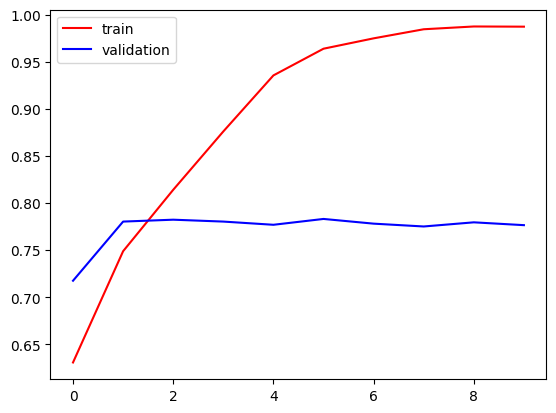

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

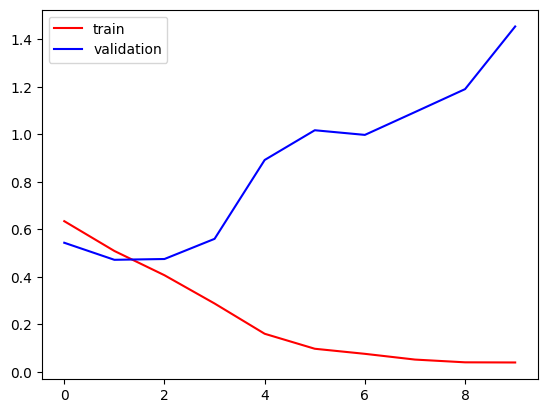

In [ ]:
plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

Ways to reduce overfitting
1) Add more Data
2) Data Augmentation
3) L1/L2 Regularization
4) Dropout Layer
5) Batch Norm
4) Reduce Complexity


In [ ]:
from keras.layers import BatchNormalization, Dropout

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size = (3,3), padding = 'valid', activation = 'relu', input_shape =(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides= 2, padding='valid'))

model.add(Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu', input_shape =(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides= 2, padding='valid'))

model.add(Conv2D(128, kernel_size = (3,3), padding = 'valid', activation = 'relu', input_shape =(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides= 2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer = 'adam', loss= 'binary_crossentropy', metrics=['accuracy'])

In [ ]:
history= model.fit(train_ds, epochs = 10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 97ms/step - accuracy: 0.5611 - loss: 1.7194 - val_accuracy: 0.6092 - val_loss: 0.6657
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.6360 - loss: 0.6510 - val_accuracy: 0.5474 - val_loss: 0.6903
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.7097 - loss: 0.5526 - val_accuracy: 0.6766 - val_loss: 0.5762
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.7625 - loss: 0.4867 - val_accuracy: 0.7480 - val_loss: 0.5283
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.8038 - loss: 0.4201 - val_accuracy: 0.7228 - val_loss: 0.5156
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8263 - loss: 0.3770 - val_accuracy: 0.7810 - val_loss: 0.4648
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.8583 - loss: 0.3163 - val_accuracy: 0.7322 - val_loss: 0.5783
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.8935 - loss: 0.2468 - 

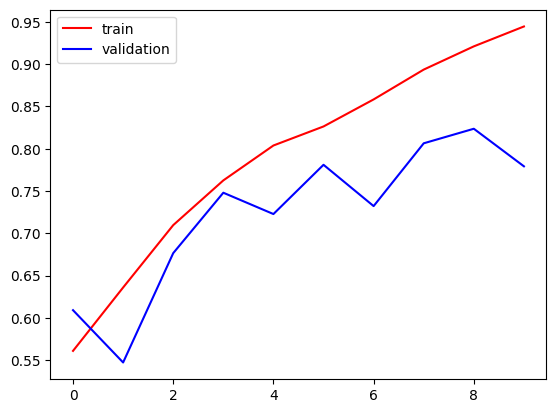

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

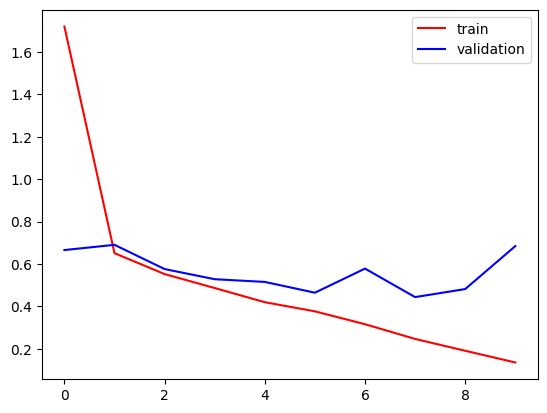

In [ ]:
plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

Image Classification on Test Image

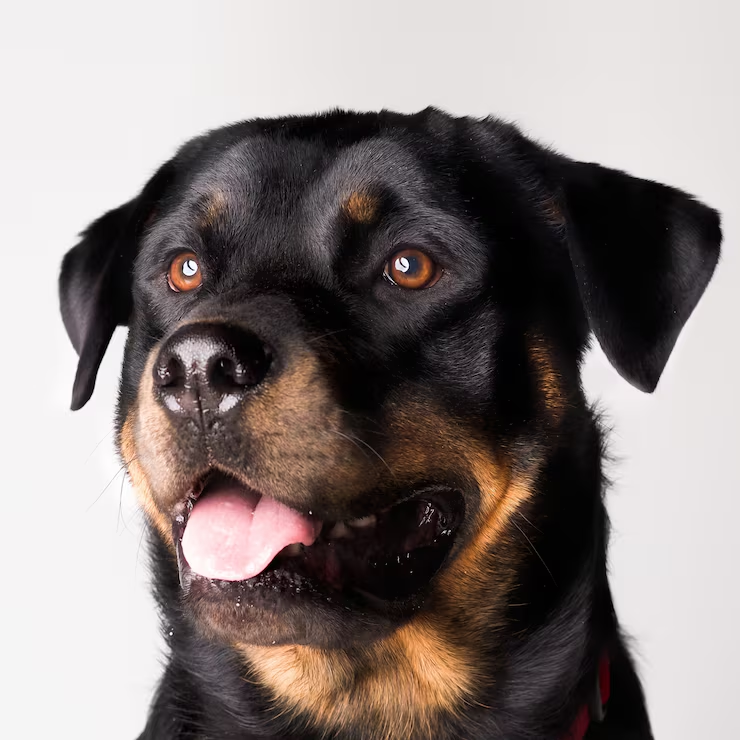

(740, 740, 3)

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
test_img = cv2.imread('/content/dog')
cv2_imshow(test_img)
test_img.shape

In [ ]:
test_img = cv2.resize(test_img, (256,256))

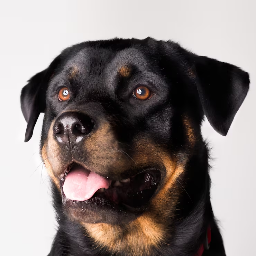

In [ ]:
cv2_imshow(test_img)

Converted into 4 D tensor

In [ ]:
test_input = test_img.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.]], dtype=float32)

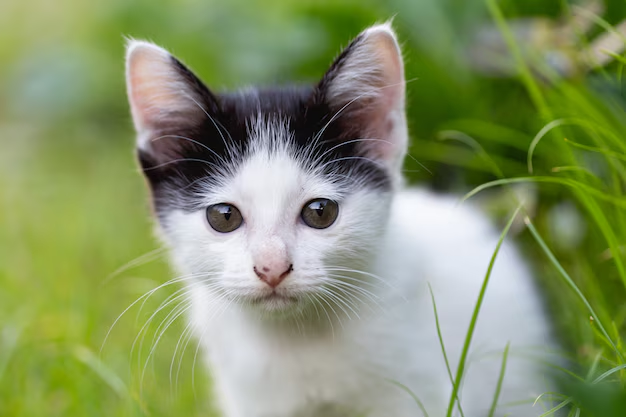

(417, 626, 3)

In [ ]:
test_img = cv2.imread('/content/cat')
cv2_imshow(test_img)
test_img.shape

In [ ]:
test_img = cv2.resize(test_img, (256,256))

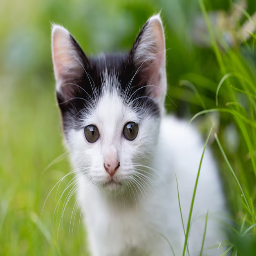

In [ ]:
cv2_imshow(test_img)

In [ ]:
test_input = test_img.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[0.]], dtype=float32)